#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [3]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [4]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

### Стандартизація датафрейму

#### Foxtrot

In [5]:
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    float64
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(2), str(6)
memory usage: 52.6 KB


In [6]:
def full_name(name: str, l: list):
    if not isinstance(name, str):
        return name
    
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"

    # Шукаємо повнішу назву у рейтингу
    for full_name in l:
        if isinstance(full_name, str) and re.search(pattern.lower(), full_name.lower()):
            return full_name
    
    return name

In [7]:
cpulist = cpu_rating['full_name'].tolist()
foxtrot['cpu'] = foxtrot['cpu'].apply(lambda x: full_name(x, cpulist))
foxtrot['product_code'] = foxtrot['product_code'].astype(int).astype(str)
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    str    
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), str(7)
memory usage: 52.6 KB


#### Brain

In [8]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     480 non-null    str    
 1   price         480 non-null    float64
 2   product_code  480 non-null    str    
 3   shop          480 non-null    str    
 4   product_url   480 non-null    str    
 5   cpu           480 non-null    str    
 6   gpu           480 non-null    str    
 7   other         480 non-null    str    
dtypes: float64(1), str(7)
memory usage: 30.1 KB


#### Telemart

In [9]:
telemart.info()
telemart['product_code'] = telemart['product_code'].astype(int).astype(str)

<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     735 non-null    str    
 1   price         735 non-null    float64
 2   product_code  735 non-null    float64
 3   shop          735 non-null    str    
 4   product_url   735 non-null    str    
 5   cpu           735 non-null    str    
 6   gpu           735 non-null    str    
 7   other         735 non-null    str    
dtypes: float64(2), str(6)
memory usage: 46.1 KB


#### CPU & GPU

In [10]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

In [11]:
cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpu_rating = gpu_rating[gpu_rating['full_name'].notna()]

In [12]:
cpu_rating.info()

<class 'pandas.DataFrame'>
Index: 3725 entries, 0 to 3729
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rate         3725 non-null   int64  
 1   full_name    3725 non-null   str    
 2   device_type  3725 non-null   str    
 3   performance  3725 non-null   float64
 4   year         3596 non-null   float64
 5   tdp          3712 non-null   float64
 6   cores        3667 non-null   float64
 7   threads      3667 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 261.9 KB


### Створення універсального датафрейму

#### Універсальний датафрейм

In [13]:
all_shop = pd.concat([brain, telemart, foxtrot])
all_shop.info()

<class 'pandas.DataFrame'>
Index: 2055 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     2055 non-null   str    
 1   price         2055 non-null   float64
 2   product_code  2055 non-null   str    
 3   shop          2055 non-null   str    
 4   product_url   2055 non-null   str    
 5   cpu           2055 non-null   str    
 6   gpu           2050 non-null   str    
 7   other         2055 non-null   str    
dtypes: float64(1), str(7)
memory usage: 144.5 KB


#### Чистка та стандартизація

In [14]:
def clean_cpu(name: str):
    name = str(name)
    name = name.strip()                    # прибирає пробіли з обох боків
    name = ' '.join(name.split())          # прибирає всі множинні пробіли
    name = name.replace('\xa0', ' ')       # нерозривний пробіл (найчастіша проблема)
    name = name.replace('\u200b', '')      # zero-width space
    if not isinstance(name, str):
        return name
    if 'Intel Core Ultra' in name:
        return name.replace('-', " ")
    return name


all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip().apply(lambda x: clean_cpu(x))

In [15]:
def clean_gpu(name):
    if not isinstance(name, str):
        return name
    if "AMD" in name:
        name = re.sub(r"\bGraphics\b", "", name).strip()
    return re.sub(r"\s+", " ", name)

gpulist = gpu_rating['full_name'].tolist()
all_shop['gpu'] = all_shop['gpu'].fillna("").apply(lambda x: full_name(x, gpulist)).apply(lambda x: clean_gpu(x))

#### Завантаження унікальних видів CPU & GPU у окемений файл 

In [16]:
all_shop['cpu'].drop_duplicates().sort_values().to_csv("data/cpu_uniqe.csv", index=False, header=False)
all_shop['gpu'].drop_duplicates().sort_values().to_csv("data/gpu_uniqe.csv", index=False, header=False)
cpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tcpu.csv", index=False, header=False)
gpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tgpu.csv", index=False, header=False)

#### Створення універсального датафрейму та оптимізація назв колонок

In [17]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:1")

In [18]:
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name',
    'rate_cpu': 'cpu_rating',
    'rate_gpu': 'gpu_rating'
    })
laptop_rating = laptop_rating.drop_duplicates()
laptop_rating.info()

<class 'pandas.DataFrame'>
Index: 2033 entries, 0 to 2054
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laptop_name      2033 non-null   str    
 1   price            2033 non-null   float64
 2   product_code     2033 non-null   str    
 3   shop             2033 non-null   str    
 4   product_url      2033 non-null   str    
 5   cpu              2033 non-null   str    
 6   gpu              2033 non-null   str    
 7   other            2033 non-null   str    
 8   cpu_rating       1882 non-null   float64
 9   cpu_name         1882 non-null   str    
 10  device_type_cpu  1882 non-null   str    
 11  performance_cpu  1882 non-null   float64
 12  year_cpu         1859 non-null   float64
 13  tdp_cpu          1880 non-null   float64
 14  cores            1875 non-null   float64
 15  threads          1875 non-null   float64
 16  gpu_rating       1757 non-null   float64
 17  gpu_name         1757 non-null

### Функція для отримання додактової характеристики

In [19]:
import ast
from typing import List

def get_spec(string: str, key: List[str] | str) -> str | None:
    try:
        d: dict = ast.literal_eval(string)
        if not isinstance(d, dict):
            return None
    except (ValueError, SyntaxError):
        return None
    
    keys = [key] if isinstance(key, str) else key

    for k in keys:
        if (res := d.get(k)) is not None:
            return res

    return None
    


### Фунція для отримання першого числового значення

In [20]:
import re

def get_numetric(string: str) -> str:
    m = re.findall(r'-?\d+', str(string))
    try:
        return m[0] if len(m)>0 else string
    except ValueError:
        print(f"Помилка обробки рядка: {m}")
        return string

# Аналіз даних

## Кількісь ноутбуків по магазинам

C:\Users\Niko.DESKTOP-QDQDF9G\AppData\Local\Temp\ipykernel_77712\1419079294.py:9: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.histplot(


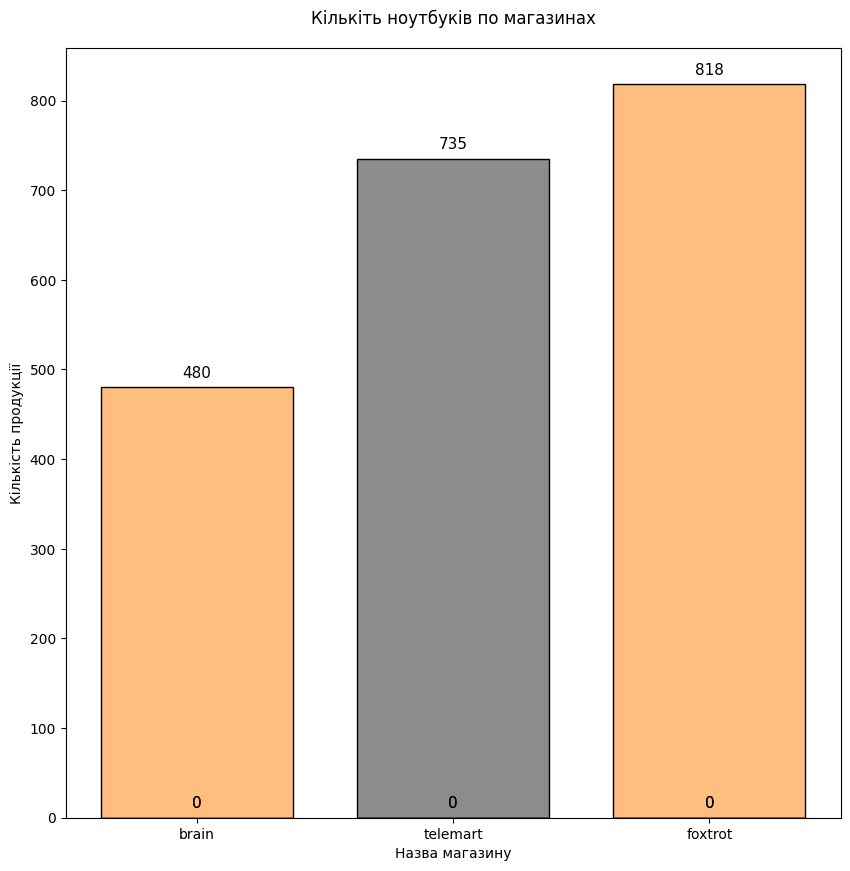

In [21]:
from typing import cast
import matplotlib.container as mcontainer


palette = ["#FF7C01", "#181A18"]


plt.figure(figsize=[10, 10])
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette=palette,
    edgecolor='black',
    legend=False, 
    cbar=True
)


for container in ax.containers:
    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=5,
        label_type='edge', 
        fmt='%d'
    )
plt.title("Кількіть ноутбуків по магазинах", y=1.02)
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()

## Середній рейтинговий показник для ноутбука 

In [22]:
laptop_rating.to_csv('laptop_rating.csv', index=False)

### Очищення Nan значень

In [23]:
df = laptop_rating
df[['cpu_rating', 'gpu_rating']] = df[['cpu_rating', 'gpu_rating']].fillna(0)

#### Формула  (cou_rating + gpu_rating) // 2

In [24]:
df["avg_perf_score"] = (df['gpu_rating'] + df['cpu_rating']) // 2

<Axes: xlabel='price', ylabel='Count'>

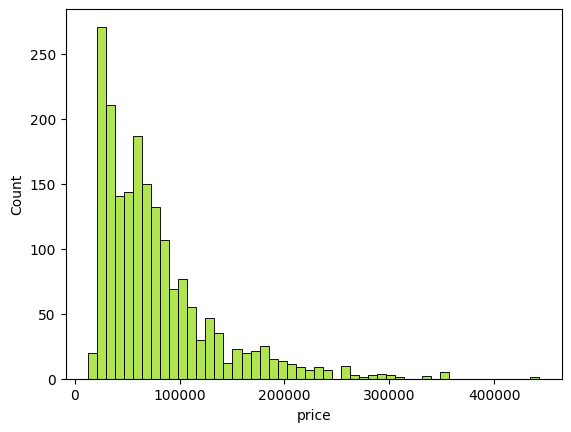

In [40]:
df = df.sort_values(by=['avg_perf_score', 'price'], ascending=True)
df = df[(df['cpu_name'].notna())]
sns.histplot(
    data=df,
    x='price',
    bins=50,
    color="#96DB15",
)

In [26]:
df[['cpu', 'cpu_name', "cpu_rating", 'gpu', 'gpu_name', 'gpu_rating', 'avg_perf_score', 'price']].sample(5)

,cpu,cpu_name,cpu_rating,gpu,gpu_name,gpu_rating,avg_perf_score,price
430,Intel Core Ultra 7 258V,Intel Core Ultra 7 258V,859.0,Intel Arc Graphics 130T,Intel Arc Graphics 130T,393.0,626.0,115755.0
1828,Intel Core Ultra 9 285HX,Intel Core Ultra 9 285HX,157.0,RTX PRO 1000,NaN,0.0,78.0,184655.0
1802,AMD Ryzen 7 7735U,AMD Ryzen 7 7735U,790.0,AMD Radeon 680M,AMD Radeon 680M,528.0,659.0,39999.0
1005,Intel Core i3-1315U,Intel Core i3-1315U,1271.0,Intel UHD Graphics 730 (Rocket Lake),Intel UHD Graphics 730 (Rocket Lake),435.0,853.0,28999.0
105,AMD Ryzen 7 260,AMD Ryzen 7 260,504.0,NVIDIA GeForce RTX 5060 Ti 16 GB,NVIDIA GeForce RTX 5060 Ti 16 GB,55.0,279.0,70999.0


In [27]:
df['shop'].describe()

count        1882
unique          3
top       foxtrot
freq          763
Name: shop, dtype: object

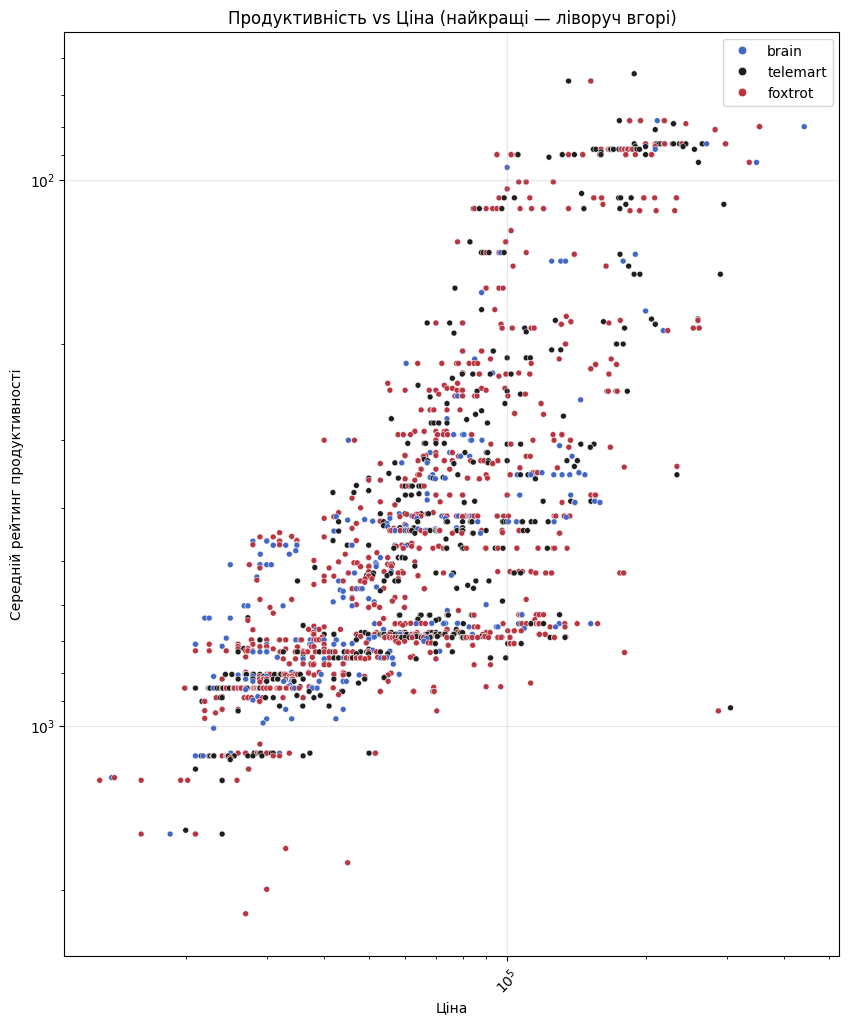

In [28]:
plt.figure(figsize=(10, 12))
ax = sns.scatterplot(
    data=df,
    x='price',
    y='avg_perf_score',
    hue='shop',
    size=1,
    palette='icefire'
)
plt.gca().invert_yaxis()

plt.title('Продуктивність vs Ціна (найкращі — ліворуч вгорі)')
plt.xlabel('Ціна')
plt.ylabel('Середній рейтинг продуктивності')

plt.xscale('log')
plt.yscale('log')


handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:-1], labels[:-1])

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

## Аналіз RAM у ноутбуках

In [29]:
df['RAM'] = df['other'] \
        .apply(lambda x: get_spec(x, ["Об'єм оперативної пам'яті", "Обсяг", "Об'єм ОЗП"])) \
        .apply(lambda x: get_numetric(x)).fillna(0).astype(int)

In [30]:
df[df['RAM']>=96][['laptop_name', 'shop', 'cpu', 'gpu', 'RAM', 'avg_perf_score']].head(10)

,laptop_name,shop,cpu,gpu,RAM,avg_perf_score
74,HP ZBook Fury G1i,brain,Intel Core Ultra 9 285HX,NVIDIA RTX PRO 5000 72 GB Blackwell,128,80.0
625,Acer Predator Helios 18 AI PH18-73 Abyssal Black,telemart,Intel Core Ultra 9 275HX,NVIDIA GeForce RTX 5090 D,96,86.0
157,Acer Predator Helios 18 PH18-73,brain,Intel Core Ultra 9 275HX,NVIDIA GeForce RTX 5090 D,192,86.0
561,Acer Predator Helios 18 AI PH18-73 Abyssal Black,telemart,Intel Core Ultra 9 275HX,NVIDIA GeForce RTX 5090 D,192,86.0
2016,Ігровий ACER Predator Helios 18 PH18-73-96KFP ...,foxtrot,Intel Core Ultra 9 275HX,NVIDIA GeForce RTX 5090 D,192,86.0
598,Asus ProArt PX13 HN7306EA-LX025X Nano Black,telemart,AMD Ryzen AI Max+ 395,AMD Raadeon RX 6600M,128,87.0
647,Asus ProArt GoPro Edition HN7306EAC-LX045X Nan...,telemart,AMD Ryzen AI Max+ 395,AMD Raadeon RX 6600M,128,87.0
580,Acer Predator Helios 18 AI PH18-73 Abyssal Black,telemart,Intel Core Ultra 9 275HX,NVIDIA GeForce RTX 5080,192,88.0
1199,HP ZBook Fury G1i 16 Meteor Silver,telemart,Intel Core Ultra 9 285HX,NVIDIA RTX PRO 4000 Blackwell,128,93.0
345,HP ZBook Fury G1i,brain,Intel Core Ultra 9 285HX,NVIDIA RTX PRO 4000 Blackwell,128,93.0


### Розподіл RAM у ноутбуках

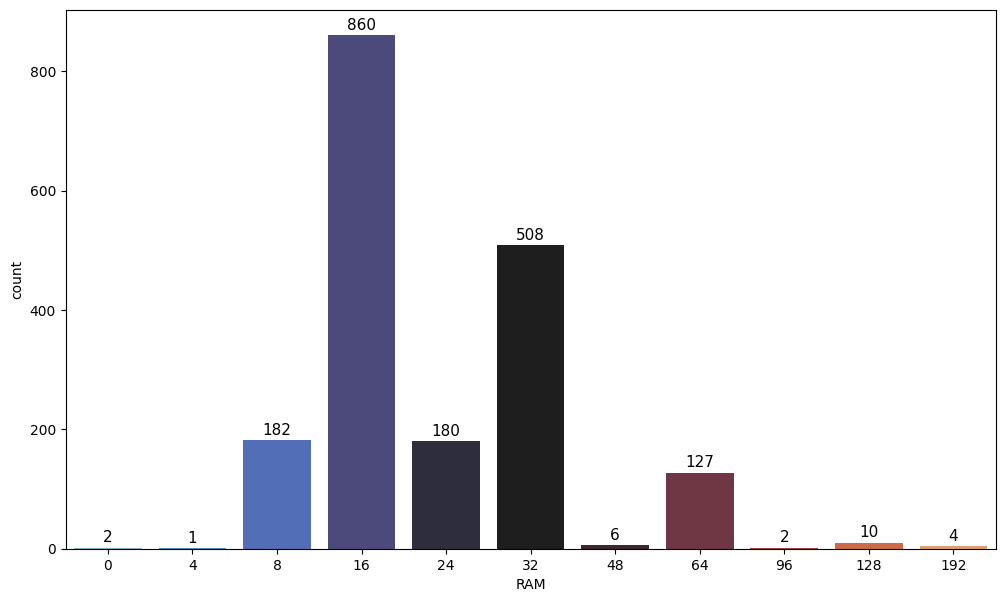

In [31]:
ram_order = sorted(df['RAM'].unique())
colors = sns.color_palette("icefire", len(ram_order))

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df,
    x='RAM',
    order=ram_order,
    hue='RAM',
    palette=colors,
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=2,
        label_type='edge', 
        fmt='%d'
    )

plt.show()


### Ціна за 1 гіг RAM

**Formula:**  (price / RAM)

In [32]:
df_ram = df[df['RAM']!=0]
df_ram['price_to_ram'] = round(df_ram['price'] / df_ram['RAM'], 2)

In [33]:
df_ram[['shop', 'product_code', 'laptop_name', 'price', 'RAM', 'price_to_ram', 'avg_perf_score']].sort_values(by=['price', 'avg_perf_score', 'price_to_ram'], ascending=[True, False, False]).head()

,shop,product_code,laptop_name,price,RAM,price_to_ram,avg_perf_score
1615,foxtrot,7265256,ACER Chromebook CB311-12H Silver,12999.0,8,1624.88,1258.0
35,brain,U1103596,Pixus Bit lite,13799.0,8,1724.88,1244.0
1929,foxtrot,7194679,PIXUS Bit Lite Grey,13999.0,8,1749.88,1244.0
1315,foxtrot,7177662,ACER Aspire Lite AL15-32P-C7E7,15999.0,8,1999.88,1578.0
1426,foxtrot,7094682,PIXUS Link Silver,15999.0,8,1999.88,1258.0


In [34]:
avg_score = df_ram.groupby('RAM')[['avg_perf_score', 'price']].mean().round(2)
avg_score = avg_score.reset_index()

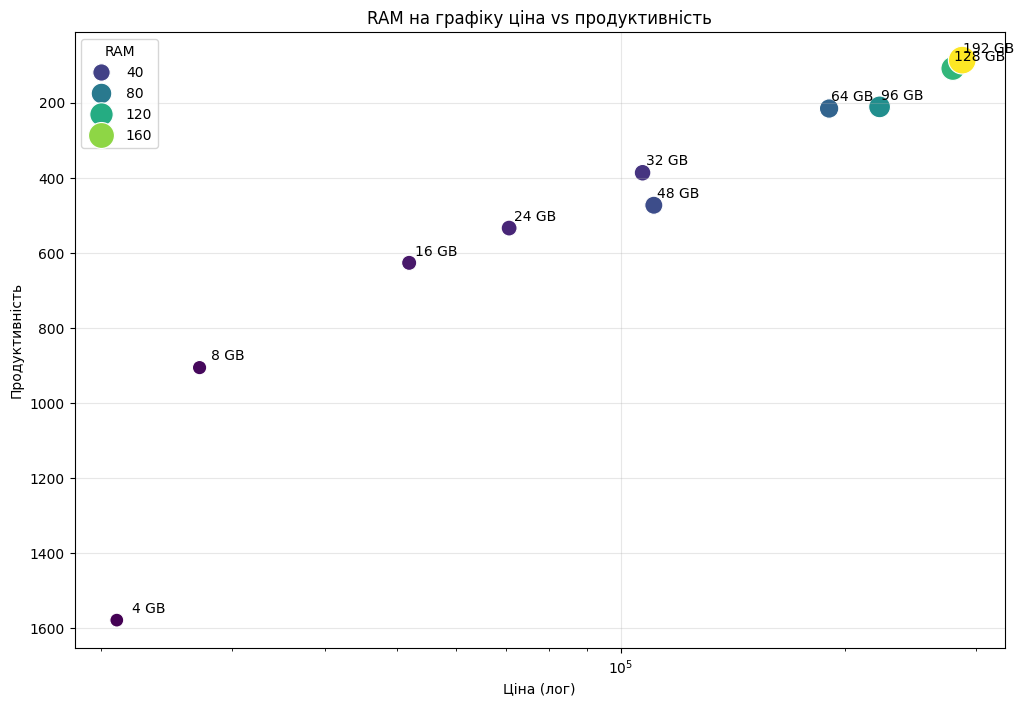

In [35]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=avg_score, x='price', y='avg_perf_score', 
                hue='RAM', size='RAM', sizes=(100, 400), palette='viridis')

for i in range(len(avg_score)):
    plt.text(avg_score['price'].iloc[i]+1000, avg_score['avg_perf_score'].iloc[i]-20, 
             f"{avg_score['RAM'].iloc[i]} GB", fontsize=10)

plt.xscale('log')
plt.gca().invert_xaxis()
plt.title('RAM на графіку ціна vs продуктивність')
plt.xlabel('Ціна (лог)')
plt.ylabel('Продуктивність')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()

## Роздільна здатність дисплею

In [36]:
df['resolution'] = df['other'].apply(lambda x: get_spec(x, ['Роздільна здатність', 'Роздільна здатність дисплея', 'Роздільність']))
df['resolution'].head()

286     3840x2400 (WQUXGA)
578              3840x2400
725              2560x1600
712              2560x1600
2029           2560 x 1600
Name: resolution, dtype: str